In [1]:
import pandas as pd
import numpy as np
import warnings
import xgboost as xgb
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import shap
import joblib

In [2]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
    --------------------------------------- 0.5/41.9 MB 493.6 kB/s eta 0:01:24
    --------------------------------------- 0.8/41.9 MB 720.4 kB/s eta 0:00:58
   - -------------------------------------- 1.0/41.9 MB 851.3 kB/s eta 0:00:48
   - -------------------------------------- 1.3/41.9 MB 940.1 kB/s eta 0:00:44
   - -------------------------------------- 1.3/41.9 MB 940.1 kB/s eta 0:00:44
   - -------------------------------------- 1.6/41.9 MB 909.4 kB/s eta 0:00:45
   - -------------------------------------- 1.8/41.9 MB 887.3 kB/s eta 0:00:46
   -- ------------------------------------- 2.1/41.9 MB 929.5 kB/s eta 0:00:43
   -- ----


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Baseline XGBoost predictions

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

print("===== BASELINE XGBOOST RESULTS =====")

print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall   :", recall_score(y_test, baseline_pred))
print("F1 Score :", f1_score(y_test, baseline_pred))
print("ROC-AUC  :", roc_auc_score(y_test, baseline_proba))

print("\nClassification Report:")
print(classification_report(y_test, baseline_pred))

NameError: name 'baseline_model' is not defined

In [4]:
%pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 906.2 kB/s eta 0:00:54
    --------------------------------------- 0.8/48.9 MB 1.2 MB/s eta 0:00:42
    --------------------------------------- 1.0/48.9 MB 1.1 MB/s eta 0:00:45
    --------------------------------------- 1.0/48.9 MB 1.1 MB/s eta 0:00:45
   - -------------------------------------- 1.3/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.6/48.9 MB 1.1 MB/s eta 0:00:45
   - -------------------------------------- 1.8/48.9 MB 1.0 MB/s eta 0:00:46
   - --------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)


XGBoost version: 3.4.1


In [37]:
df = pd.read_csv('PreProcessed_IBM_Telco_Customer_Churn_Cleaned.csv')
df = df.drop(columns=['customerID'])

print(df.shape)
print(df['Churn'].value_counts(normalize=True))

(7043, 22)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [38]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df[c] = df[c].map({'Yes': 1, 'No': 0})

collapse_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
for c in collapse_cols:
    df[c] = df[c].replace({'No internet service': 'No', 'No phone service': 'No'})
    df[c] = df[c].map({'Yes': 1, 'No': 0})
df['TenureGroup'] = df['TenureGroup'].map({'0-1 Year': 0, '1-2 Years': 1, '2-4 Years': 2, '4-6 Years': 3})
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['Churn'])
y = df['Churn']
print(X.shape)   

(7043, 25)


In [3]:
# Separate features and target

X = df.drop(columns=['Churn'])
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

NameError: name 'df' is not defined

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {neg}/{pos} = {spw:.4f}')

NameError: name 'X' is not defined

In [40]:
results = {}

baseline_model = XGBClassifier(random_state=42, eval_metric='logloss')
baseline_model.fit(X_train, y_train)

pred = baseline_model.predict(X_test)
proba = baseline_model.predict_proba(X_test)[:, 1]

results['Baseline'] = {
    'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred),
    'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
    'ROC-AUC': roc_auc_score(y_test, proba)
}
print(results['Baseline'])
print(confusion_matrix(y_test, pred))

{'Accuracy': 0.7792760823278921, 'Precision': 0.5987460815047022, 'Recall': 0.5106951871657754, 'F1': 0.5512265512265512, 'ROC-AUC': 0.8246596398770312}
[[907 128]
 [183 191]]


In [41]:
churn_idx = y_test[y_test == 1].index[:3]
no_churn_idx = y_test[y_test == 0].index[:3]
sample_idx = churn_idx.append(no_churn_idx)

X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx].values
dsample = xgb.DMatrix(X_sample)
dtrain = xgb.DMatrix(X_train, label=y_train)

trace_params = {'max_depth': 3, 'eta': 0.3, 'objective': 'binary:logistic',
                 'eval_metric': 'logloss', 'scale_pos_weight': spw}

booster = None
for round_num in range(1, 4):
    prob_before = np.full(len(sample_idx), y_train.mean()) if booster is None else booster.predict(dsample)
    residual = y_sample - prob_before

    booster = xgb.train(trace_params, dtrain, num_boost_round=1, xgb_model=booster)

    prob_after = booster.predict(dsample)
    tbl = pd.DataFrame({'CustomerID': sample_idx, 'ActualChurn': y_sample,
                         'Prob_Before': prob_before.round(4), 'Residual': residual.round(4),
                         'Prob_After': prob_after.round(4)})
    print(f'--- Round {round_num} ---')
    print(tbl.to_string(index=False))
    print()
    print('Tree added this round:')
    print(booster.get_dump()[-1])
    print('=' * 70)

--- Round 1 ---
 CustomerID  ActualChurn  Prob_Before  Residual  Prob_After
       1639            1       0.2654    0.7346      0.5043
       3524            1       0.2654    0.7346      0.5809
       6529            1       0.2654    0.7346      0.5809
        437            0       0.2654   -0.2654      0.3673
       2280            0       0.2654   -0.2654      0.5809
       2235            0       0.2654   -0.2654      0.3883

Tree added this round:
0:[Contract_Two year<1] yes=1,no=2,missing=2
	1:[Contract_One year<1] yes=3,no=4,missing=4
		3:[InternetService_Fiber optic<1] yes=7,no=8,missing=8
			7:leaf=0.0171972569
			8:leaf=0.326451987
		4:[StreamingMovies<1] yes=9,no=10,missing=10
			9:leaf=-0.454408079
			10:leaf=-0.128598288
	2:[MonthlyCharges<103.300003] yes=5,no=6,missing=6
		5:[PaymentMethod_Electronic check<1] yes=11,no=12,missing=12
			11:leaf=-0.554910004
			12:leaf=-0.411475211
		6:[TotalCharges<7746.7002] yes=13,no=14,missing=14
			13:leaf=-0.181595862
			14:leaf=-0

In [42]:
weighted_model = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw)
weighted_model.fit(X_train, y_train)

pred = weighted_model.predict(X_test)
proba = weighted_model.predict_proba(X_test)[:, 1]

results['Class-Weighted'] = {
    'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred),
    'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
    'ROC-AUC': roc_auc_score(y_test, proba)
}
print(results['Class-Weighted'])

{'Accuracy': 0.7615330021291696, 'Precision': 0.5389344262295082, 'Recall': 0.7032085561497327, 'F1': 0.6102088167053364, 'ROC-AUC': 0.8182631946059057}


In [43]:
param_dist = {
    'n_estimators':     [100, 200, 300, 400, 500],
    'max_depth':        [3, 4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.02, 0.05, 0.08, 0.1, 0.15],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha':        [0, 0.01, 0.1, 1],
    'reg_lambda':       [0.5, 1, 1.5, 2, 3],
}

base = XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=spw)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(base, param_distributions=param_dist, n_iter=40,
                             scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print('Best CV ROC-AUC:', search.best_score_)
print('Best params:', search.best_params_)

Best CV ROC-AUC: 0.8497040529692084
Best params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.02, 'gamma': 0.2, 'colsample_bytree': 0.6}


In [44]:
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

params = dict(search.best_params_)
params['n_estimators'] = 2000

final_model = XGBClassifier(random_state=42, eval_metric='auc', scale_pos_weight=spw,
                             early_stopping_rounds=30, **params)
final_model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

print('Trees actually used:', final_model.best_iteration)

pred = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)[:, 1]

results['Tuned (Final)'] = {
    'Accuracy': accuracy_score(y_test, pred), 'Precision': precision_score(y_test, pred),
    'Recall': recall_score(y_test, pred), 'F1': f1_score(y_test, pred),
    'ROC-AUC': roc_auc_score(y_test, proba)
}
print(results['Tuned (Final)'])
print(confusion_matrix(y_test, pred))

Trees actually used: 239
{'Accuracy': 0.7423704755145494, 'Precision': 0.5092748735244519, 'Recall': 0.8074866310160428, 'F1': 0.6246122026887281, 'ROC-AUC': 0.8463238523340826}
[[744 291]
 [ 72 302]]


              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



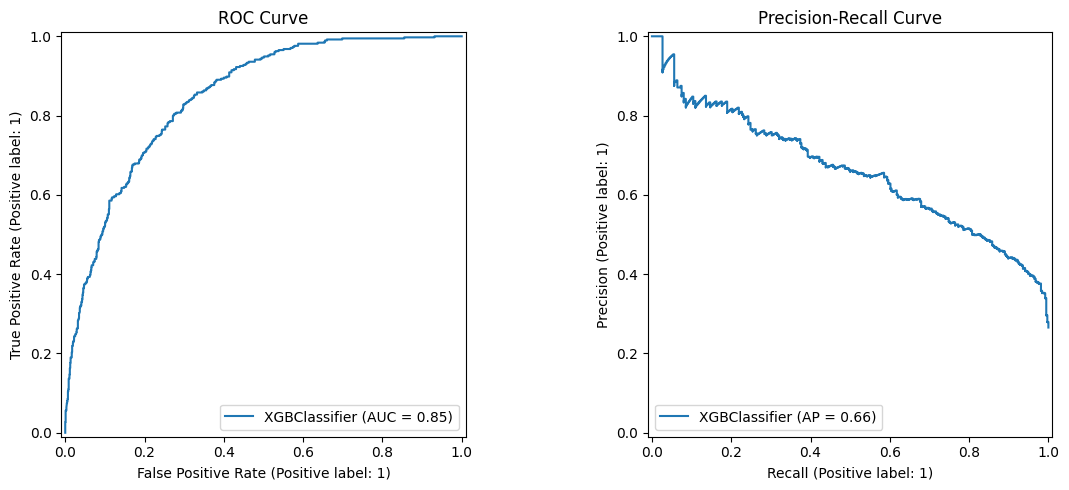

In [45]:
print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[0])
axes[0].set_title('ROC Curve')
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



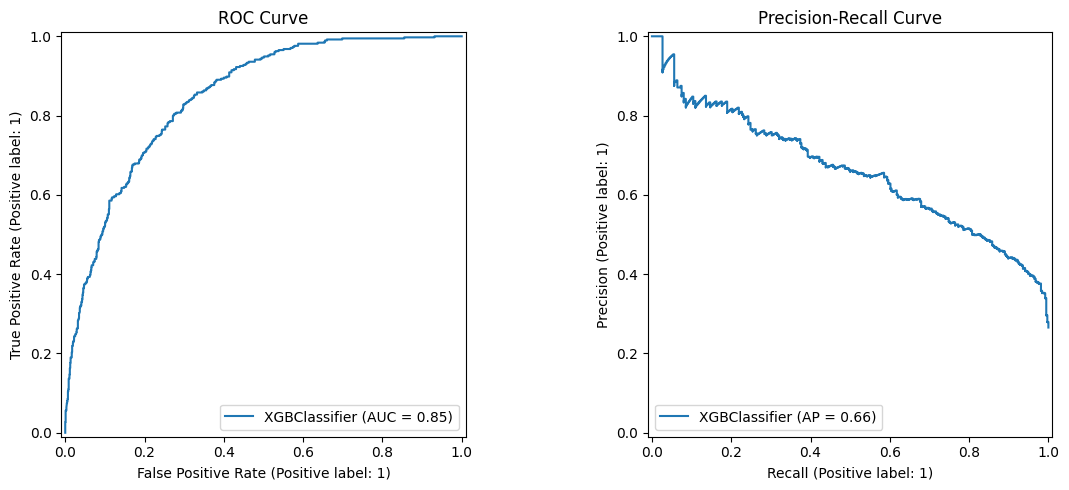

In [46]:
print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[0])
axes[0].set_title('ROC Curve')
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout(); plt.show()

                Accuracy  Precision  Recall      F1  ROC-AUC
Baseline          0.7793     0.5987  0.5107  0.5512   0.8247
Class-Weighted    0.7615     0.5389  0.7032  0.6102   0.8183
Tuned (Final)     0.7424     0.5093  0.8075  0.6246   0.8463


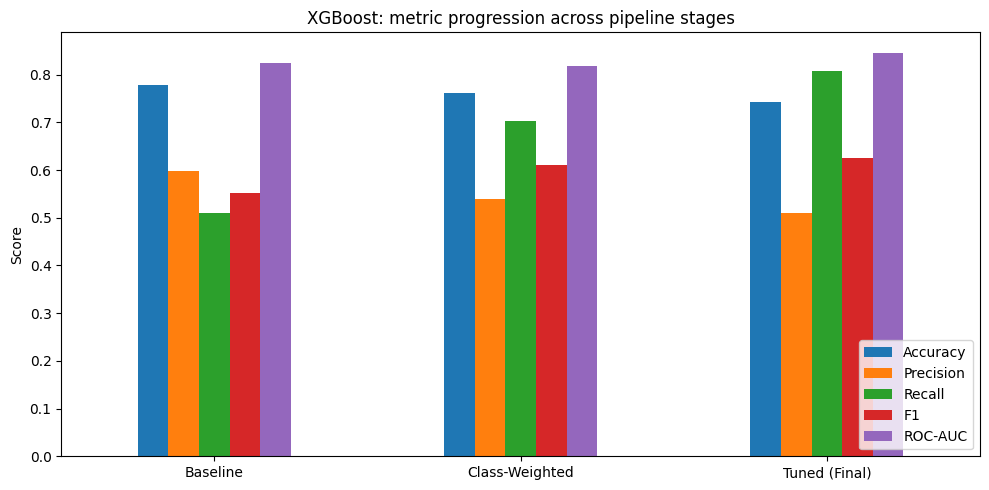

In [47]:
comp_df = pd.DataFrame(results).T
print(comp_df.round(4))

comp_df.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Score'); plt.title('XGBoost: metric progression across pipeline stages')
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()